In [1]:
# Imports principais e checagem de dependências
import importlib
import sys

required = ["pandas", "numpy", "matplotlib", "seaborn", "sklearn"]
missing = []
for pkg in required:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Instalando pacotes faltantes:", missing)
    !{sys.executable} -m pip install -q 

In [2]:
# Importar bibliotecas após garantir instalação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8')


In [3]:
# Carregar dataset
file_path = r"c:\\Users\\ediad\\OneDrive\\Área de Trabalho\\Predictive-Analysis-1\\telco-customer-churn\\WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Inspeção inicial
print("Tipos:\n", df.dtypes)
print("\nValores ausentes por coluna:\n", df.isna().sum())
print("\nValores ' ' (strings vazias) em TotalCharges:", (df['TotalCharges'] == ' ').sum())


Tipos:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores ausentes por coluna:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paperle

In [5]:
# Pré-processamento
# 1. Limpar TotalCharges: converter para float, tratando espaços vazios
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Tratar missing (TotalCharges) imputando pela mediana
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Codificar variável alvo
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

# 4. Remover identificador
df_model = df.drop(columns=['customerID', 'Churn'])

# 5. Separar numéricas e categóricas
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

# 6. Dummies (drop_first=True)
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# 7. Escalar numéricas (StandardScaler) - apenas colunas originais numéricas (exceto alvo)
scaler = StandardScaler()
num_cols_no_target = [c for c in numeric_cols if c != 'ChurnFlag']
df_encoded[num_cols_no_target] = scaler.fit_transform(df_encoded[num_cols_no_target])

# 8. Separar X e y
X = df_encoded.drop(columns=['ChurnFlag'])
y = df_encoded['ChurnFlag']

# 9. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Shape treino:", X_train.shape, "| teste:", X_test.shape)
print("Percentual churn treino:", y_train.mean().round(3), "| teste:", y_test.mean().round(3))


Shape treino: (5634, 30) | teste: (1409, 30)
Percentual churn treino: 0.265 | teste: 0.265


In [6]:
# Definição e treinamento dos modelos
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=None),
    'Bagging': BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42, max_depth=None),
                                 n_estimators=50, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42, max_depth=None),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    trained_models[name] = mdl
    y_pred = mdl.predict(X_test)
    # Para AUC, usar predict_proba se disponível, senão decision_function
    if hasattr(mdl, 'predict_proba'):
        y_scores = mdl.predict_proba(X_test)[:,1]
    else:
        y_scores = mdl.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores)
    f1 = f1_score(y_test, y_pred)
    results.append({'Modelo': name, 'Accuracy': acc, 'ROC_AUC': auc, 'F1': f1})

metrics_df = pd.DataFrame(results).sort_values(by='ROC_AUC', ascending=False)
metrics_df.reset_index(drop=True, inplace=True)
metrics_df

,Modelo,Accuracy,ROC_AUC,F1
0,AdaBoost,0.804826,0.843150,0.587706
1,GradientBoosting,0.799148,0.842683,0.576981
2,RandomForest,0.792051,0.826782,0.562033
3,Bagging,0.787793,0.812825,0.562225
4,DecisionTree,0.742370,0.662780,0.504775


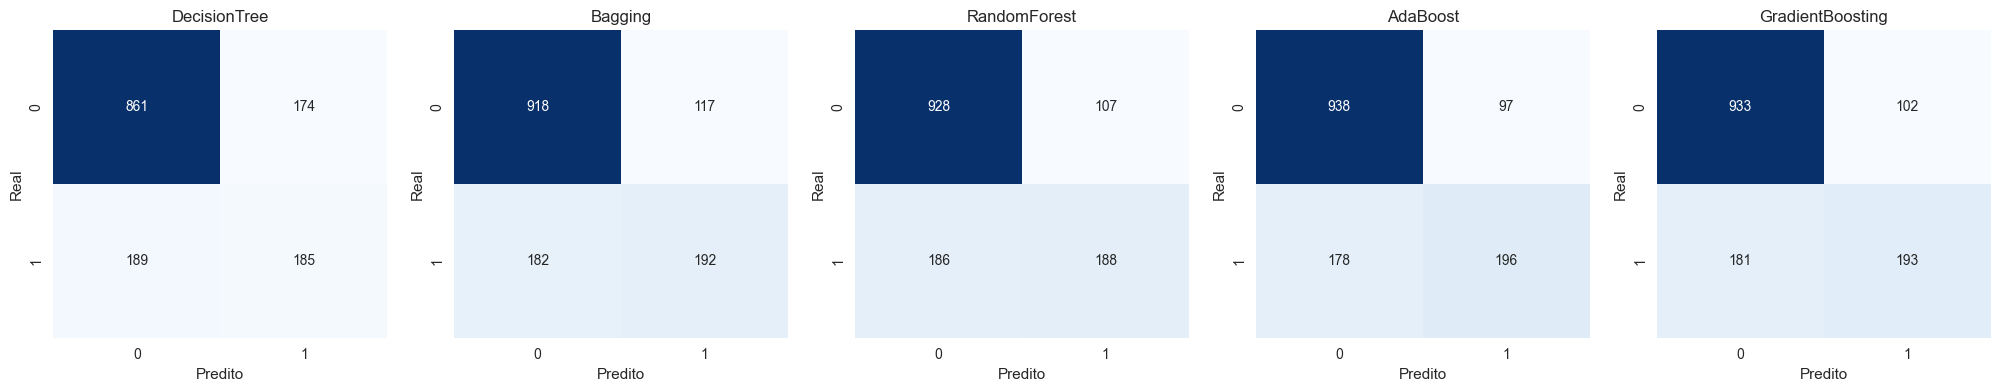

In [7]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(5*len(trained_models), 4))
if len(trained_models) == 1:
    axes = [axes]
for ax, (name, mdl) in zip(axes, trained_models.items()):
    y_pred = mdl.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
plt.savefig('confusion_matrices_ensemble_models_horizontal.png')
plt.show()


<Figure size 200x200 with 0 Axes>

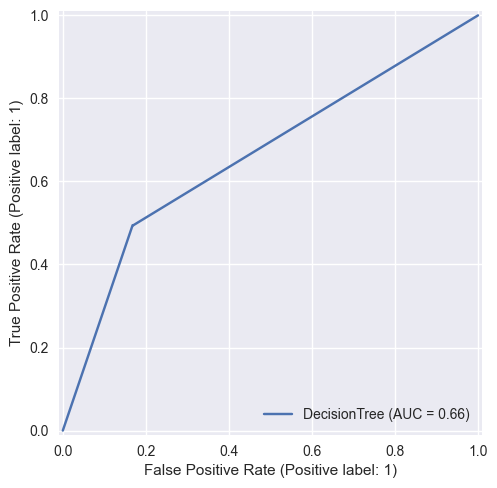

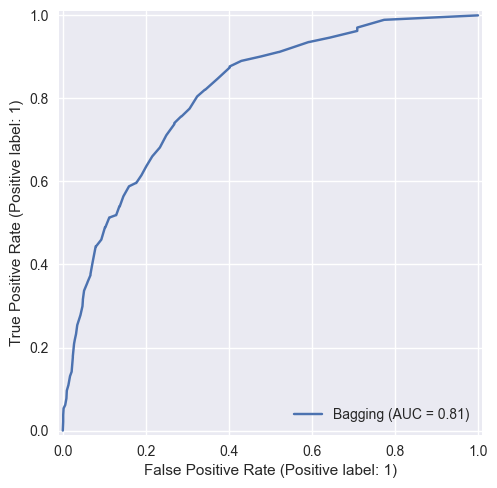

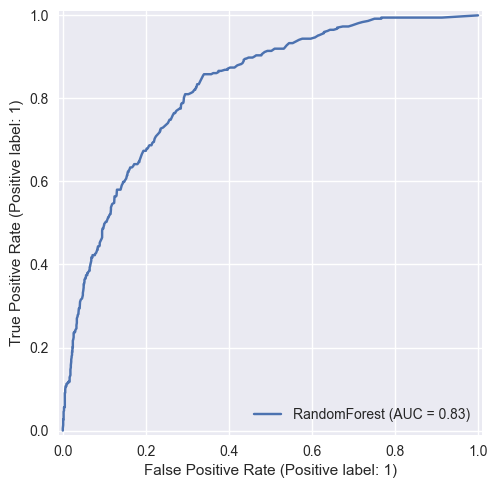

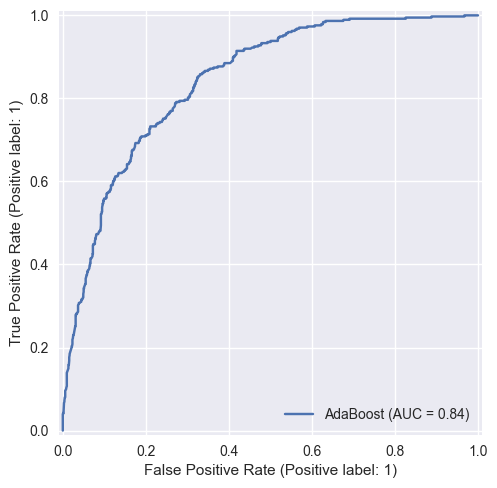

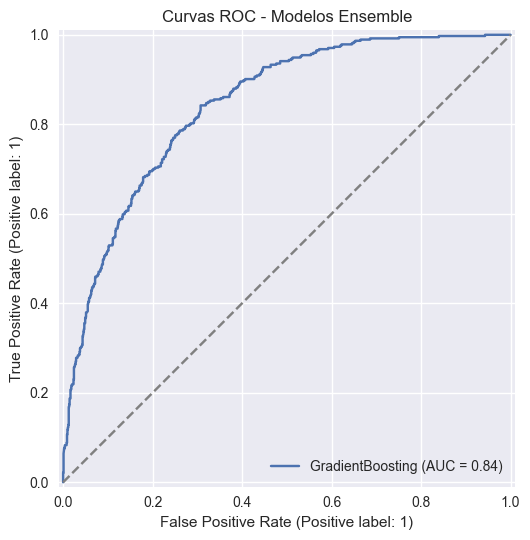

In [9]:
# Curvas ROC comparativas
plt.figure(figsize=(2,2))
for name, mdl in trained_models.items():
    if hasattr(mdl, 'predict_proba'):
        y_scores = mdl.predict_proba(X_test)[:,1]
    else:
        y_scores = mdl.decision_function(X_test)
    RocCurveDisplay.from_predictions(y_test, y_scores, name=name)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('Curvas ROC - Modelos Ensemble')
plt.tight_layout()
plt.savefig('roc_curves_ensemble_models.png')
plt.show()


In [10]:
# Importância das variáveis (Permutation Importance)
feature_importances = {}
for name, mdl in trained_models.items():
    r = permutation_importance(mdl, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    importances = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
    feature_importances[name] = importances

# Exibir top 10 de cada modelo
for name, imp in feature_importances.items():
    print(f"\nTop 10 features - {name}")
    print(imp.head(10))

# Consolidar frequência das top variáveis
freq = pd.Series(dtype=int)
for name, imp in feature_importances.items():
    top10 = imp.head(10).index
    freq = freq.add(pd.Series(1, index=top10), fill_value=0)
print("\nFrequência de aparição nas top10:")
print(freq.sort_values(ascending=False))



Top 10 features - DecisionTree
tenure                                  0.073811
TotalCharges                            0.068204
MonthlyCharges                          0.046913
DeviceProtection_No internet service    0.025124
Contract_Two year                       0.024273
InternetService_Fiber optic             0.019872
Contract_One year                       0.011923
MultipleLines_Yes                       0.010433
PaperlessBilling_Yes                    0.008730
TechSupport_Yes                         0.007026
dtype: float64

Top 10 features - Bagging
tenure                         0.046345
InternetService_Fiber optic    0.033357
TotalCharges                   0.017388
MonthlyCharges                 0.009581
TechSupport_Yes                0.006671
PaperlessBilling_Yes           0.006317
SeniorCitizen                  0.005891
Partner_Yes                    0.005536
Contract_One year              0.004968
StreamingMovies_Yes            0.004258
dtype: float64

Top 10 features - Ra

In [11]:
# Preparar objetos para escrita do relatório markdown
# Selecionar métricas principais e top features globais
metrics_df.to_csv('telco_metrics.csv', index=False)
freq.sort_values(ascending=False).to_csv('telco_feature_frequency.csv')
print("Arquivos 'telco_metrics.csv' e 'telco_feature_frequency.csv' salvos.")


Arquivos 'telco_metrics.csv' e 'telco_feature_frequency.csv' salvos.


In [12]:
# Resumo estatístico das principais variáveis numéricas
numeric_summary = df[['tenure','MonthlyCharges','TotalCharges']].describe().T
print(numeric_summary)
numeric_summary.to_csv('telco_numeric_summary.csv')
print("Resumo numérico salvo em telco_numeric_summary.csv")

                 count         mean          std    min      25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.000    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.500    70.350   
TotalCharges    7043.0  2281.916928  2265.270398  18.80  402.225  1397.475   

                    75%      max  
tenure            55.00    72.00  
MonthlyCharges    89.85   118.75  
TotalCharges    3786.60  8684.80  
Resumo numérico salvo em telco_numeric_summary.csv
